# EdgeAI Assignment – Student Notebook (Starter)

**Course:** Embedded Systems / EdgeAI (UCSC Extension)

**Assignment:** End-to-End EdgeAI Pipeline with OpenMV

## Build a camera-based gesture detector that recognizes LEFT, RIGHT, or NONE and triggers logic on-device — no cloud, no PC at runtime.

---

This notebook guides you through building a complete EdgeAI pipeline using data captured on an OpenMV camera and training/quantizing a small CNN using TensorFlow Lite.

```
PC
 ├─ Data capture
 ├─ Keras training
 ├─ INT8 quantization
 ├─ TFLite export
 ↓
OpenMV
 ├─ TFLite Micro runtime
 ├─ CNN inference
 ├─ Symbolic FSM
 └─ Actuation
```
### Gesture Suggestions
- use left hand and right hand
- use variations for 'none'

![alt text](https://drive.google.com/uc?export=view&id=13Re69BzFl10PgaKo9ewNKT_E8gWpwyPz)

## 1. Data Capture with OpenMV (Manual Step)

Use the OpenMV IDE to capture grayscale 64×64 images.
Run this code inside the OpenVM, which will capture an image twice per second

```python
import sensor, image, time, os, pyb

# configure camera (ML-safe)
sensor.reset()
sensor.set_pixformat(sensor.GRAYSCALE)
sensor.set_framesize(sensor.B64X64)

# Auto exposure/gain changes image statistics frame-to-frame
# That injects label-independent variance
# Small models (64×64!) are very sensitive to this
sensor.set_auto_gain(False)
sensor.set_auto_whitebal(False)   # harmless in GRAYSCALE, still disable
sensor.set_auto_exposure(False)

# fix exposure/gain explicitly (advanced, but ideal):
sensor.set_exposure_us(5000)
sensor.set_gain_db(0)

sensor.skip_frames(time=2000)

# ----------------------------
# Dataset configuration
# ----------------------------
LABELS = ["LEFT", "RIGHT", "NONE"]
label_index = 0
samples_per_label = 50  # change as needed

BASE_PATH = "/sd"
btn = pyb.Switch()

# Create directories
for lbl in LABELS:
    path = "%s/%s" % (BASE_PATH, lbl)
    if lbl not in os.listdir(BASE_PATH):
        os.mkdir(path)

print("=== DATASET CAPTURE MODE ===")
print("Press button to capture image")
print("Hold button (>1s) to switch label")

# ----------------------------
# Helper functions
# ----------------------------
def wait_for_release():
    while btn():
        time.sleep_ms(10)

def next_label():
    global label_index
    label_index = (label_index + 1) % len(LABELS)
    print("\n>>> SWITCH TO:", LABELS[label_index])

# ----------------------------
# Capture loop
# ----------------------------
while True:
    label = LABELS[label_index]
    path = "%s/%s" % (BASE_PATH, label)

    counter = len(os.listdir(path))

    print("\nLabel:", label)
    print("Samples:", counter, "/", samples_per_label)

    # Capture preview (not saved)
    sensor.snapshot()

    if btn():
        t0 = time.ticks_ms()

        # Button still pressed?
        while btn():
            time.sleep_ms(10)

        dt = time.ticks_diff(time.ticks_ms(), t0)

        # Long press → switch label
        if dt > 1000:
            next_label()
            time.sleep_ms(300)
            continue

        # Short press → capture
        img = sensor.snapshot()
        filename = "%s/%03d.pgm" % (path, counter)
        img.save(filename)

        print("Saved:", filename)

        time.sleep_ms(300)  # debounce

```

## 2. Upload Dataset to Colab
Download the images, mount the SD card from the camera, download and zip the dataset.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving hand_gestures.zip to hand_gestures.zip


In [3]:
import zipfile, os

zip_path = "hand_gestures.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")

os.listdir("hand_gestures")

['LEFT', 'RIGHT', 'NONE']

## 3. Dataset Loading and Preprocessing

In [4]:
import os
import numpy as np
from PIL import Image

LABELS = {"NONE": 0, "LEFT": 1, "RIGHT": 2}

def load_dataset(root_dir):
    X, y = [], []
    for label, idx in LABELS.items():
        folder = os.path.join(root_dir, label)
        for fname in os.listdir(folder):
            img = Image.open(os.path.join(folder, fname))
            # Resize image to 64x64 as required by the model
            # img = img.resize((64, 64))
            arr = np.array(img, dtype=np.float32)

            # Normalize image to [0,1]
            arr = arr / 255.0
            # Add channel dimension for Keras (64, 64) -> (64, 64, 1)
            arr = arr.reshape((64, 64, 1))

            # Append to X
            X.append(arr)
            # Append to y
            y.append(idx)

    return np.array(X), np.array(y)

# Load dataset
X, y = load_dataset("hand_gestures")

print(f"Loaded {len(X)} images with shape {X.shape} and {len(y)} labels.")

Loaded 150 images with shape (150, 64, 64, 1) and 150 labels.


## 4. Train / Validation Split

In [5]:
from sklearn.model_selection import train_test_split

# Perform train/validation split (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (120, 64, 64, 1)
y_train shape: (120,)
X_val shape: (30, 64, 64, 1)
y_val shape: (30,)


## 5. Model Definition
📌 **How to Construct the Neural Network**

In this assignment, you are not designing a general-purpose neural network.
You are building a very small, efficient classifier that must run on an embedded device with strict memory and compute limits.

Because of these constraints, the network structure is intentionally simple and follows a proven pattern for tiny vision models.

🧠 **What the network needs to do**

Your neural network must:

1. Accept a 64×64 grayscale image
2. Extract simple visual features (edges, motion patterns)
3. Combine those features into a compact representation
4. Output three probabilities:

- NONE
- LEFT
- RIGHT

To do this efficiently, we use a Convolutional Neural Network (CNN).

🧩 **Required building blocks (in order)**

Your model should contain the following components in this order:

---
1️⃣ **Input layer (implicit or explicit)**

- The input to the network is a 64×64 image with one channel.
- In Keras, this is usually specified once at the start:

`layers.Input(shape=(64, 64, 1))`


Why this exists
- Tells the network the shape of incoming data
- Required for model conversion and deployment

2️⃣ **First convolution layer (feature extraction)**

`layers.Conv2D(8, (3, 3), activation="relu")`

What it does
- Slides small 3×3 filters across the image
- Detects simple patterns like:
  - edges
  - corners
  - motion direction hints

Why only 8 filters
- Embedded systems have limited memory
- Fewer filters = fewer parameters = smaller model

3️⃣ **Downsampling (reduce size, increase robustness)**

`layers.MaxPooling2D()`

What it does
- Reduces spatial resolution
- Keeps the strongest features
- Makes the model more tolerant to small shifts

Why this matters
- Reduces computation
- Prevents overfitting
- Essential for embedded performance

4️⃣ **Second convolution layer (higher-level features)**

`layers.Conv2D(16, (3, 3), activation="relu")`

What it does
- Combines simple features into more meaningful ones
- Learns patterns related to motion direction

Why 16 filters
- Slightly more expressive than the first layer
- Still small enough for OpenMV

5️⃣ **Global Average Pooling (critical for embedded)**

`layers.GlobalAveragePooling2D()`

What it does
- Converts feature maps into a single feature vector
- Replaces large fully connected layers

Why this is important
- Dramatically reduces parameter count
- Improves generalization
- Common in production EdgeAI models

⚠️ **This layer is one of the main reasons the model fits on OpenMV.**

6️⃣ **Output layer (classification)**

`layers.Dense(3, activation="softmax")`

What it does
- Produces one probability per class
- Ensures outputs sum to 1.0

Why 3 outputs
- One for each gesture class

🧪 **Putting it all together**

Your final model should conceptually look like this:
```
Input (64×64×1)
 ↓
Conv2D (8 filters)
 ↓
MaxPooling
 ↓
Conv2D (16 filters)
 ↓
GlobalAveragePooling
 ↓
Dense (3 outputs)
```

*This is not arbitrary — it is a standard, well-tested pattern for tiny vision models.*

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the small CNN model
model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(), # Added another MaxPooling2D layer
    layers.Conv2D(64, (3, 3), activation="relu"), # Added another Conv2D layer with more filters
    layers.GlobalAveragePooling2D(),
    layers.Dense(3, activation="softmax")
])

# Use Adam optimizer with sparse_categorical_crossentropy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,491 (91.76 KB)

 Trainable params: 23,491 (91.76 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

## 9.2 Hyperparameter Tuning with Callbacks

To further optimize training and prevent overfitting, we'll introduce Keras Callbacks for learning rate scheduling and early stopping.

In [7]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define Learning Rate Scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', # Monitor validation loss
    factor=0.5,         # Reduce learning rate by half
    patience=5,         # If no improvement for 5 epochs
    min_lr=1e-6,        # Minimum learning rate
    verbose=1
)

# Define Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10,        # Stop if no improvement for 10 epochs
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    verbose=1
)

print("LearningRateScheduler and EarlyStopping callbacks defined.")

LearningRateScheduler and EarlyStopping callbacks defined.


Now, let's retrain the model with these new callbacks.

In [8]:
# Retrain the model with the original data and callbacks
history_tuned = model.fit(
    X_train,
    y_train, # Use integer labels
    epochs=100,        # Increase epochs, EarlyStopping will prevent overfitting
    validation_data=(X_val, y_val), # Use integer labels
    callbacks=[lr_scheduler, early_stopping] # Add the callbacks
)

# Evaluate the model on the validation set after training
loss_tuned, accuracy_tuned = model.evaluate(X_val, y_val)
print(f"Validation Loss after tuned training: {loss_tuned:.4f}")
print(f"Validation Accuracy after tuned training: {accuracy_tuned:.4f}")

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.2833 - loss: 1.1016 - val_accuracy: 0.3000 - val_loss: 1.0938 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3417 - loss: 1.0899 - val_accuracy: 0.3000 - val_loss: 1.0873 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3417 - loss: 1.0833 - val_accuracy: 0.3000 - val_loss: 1.0786 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3417 - loss: 1.0734 - val_accuracy: 0.3000 - val_loss: 1.0683 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3417 - loss: 1.0599 - val_accuracy: 0.3000 - val_loss: 1.0556 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3417 - loss: 1.0447 - val_accuracy: 0.4000 - val_loss: 1.0344 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5917 - loss: 1.0255 - val_accur

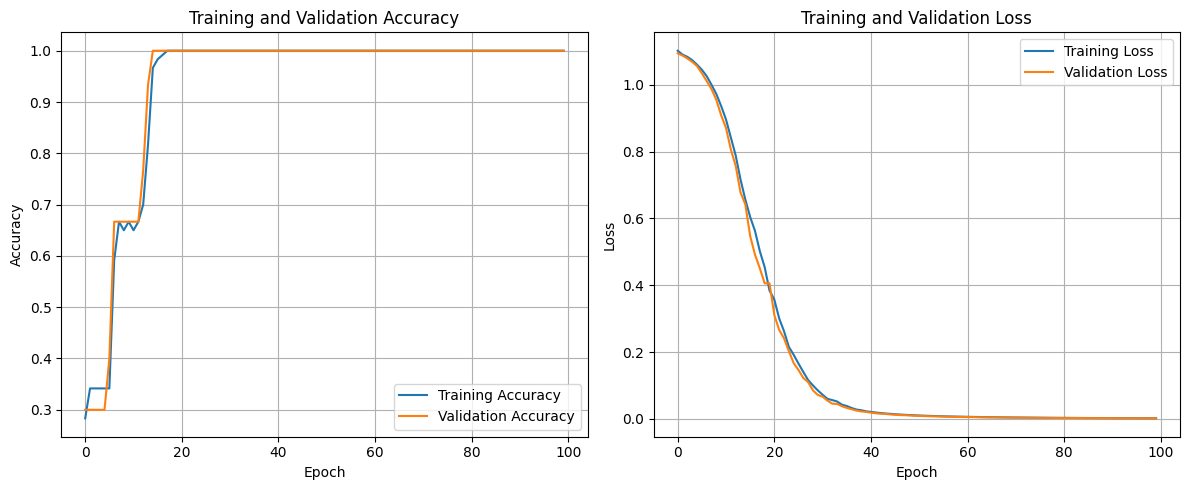

In [9]:
import matplotlib.pyplot as plt

# Plotting training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history_tuned.history['accuracy'], label='Training Accuracy')
plt.plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history_tuned.history['loss'], label='Training Loss')
plt.plot(history_tuned.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Post-Training Quantization (INT8)

In [10]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Define representative dataset generator
def representative_dataset_generator():
    for i in range(X_train.shape[0]):
        # Ensure the input is a float32 tensor with batch dimension (1, 64, 64, 1)
        input_tensor = tf.convert_to_tensor(X_train[i:i+1], dtype=tf.float32)
        yield [input_tensor]

converter.representative_dataset = representative_dataset_generator
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # Reactivated: force input type to int8
converter.inference_output_type = tf.int8 # Reactivated: force output type to int8
converter._experimental_disable_per_channel_quantization_for_dense_layers = True # fix for failure to allocate tensors error

tflite_model = converter.convert()

with open("gesture_int8.tflite", "wb") as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmp66snmehq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136800003139024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136800003140176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136800003140560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136800003139600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136800003141328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136800003141520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136800003137680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136800003139216: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [11]:
import os

tflite_model_path = "gesture_int8.tflite"
model_size_bytes = os.path.getsize(tflite_model_path)
model_size_kb = model_size_bytes / 1024

print(f"TFLite model size: {model_size_bytes} bytes ({model_size_kb:.2f} KB)")

TFLite model size: 30424 bytes (29.71 KB)


## 8. TFLite Model Validation

Sample Image (Actual Label: LEFT)
Predicted Label: LEFT with confidence: 0.58


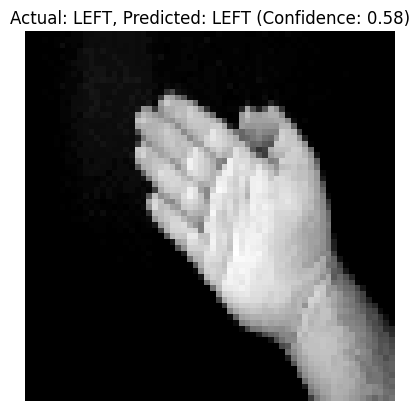

In [13]:
import numpy as np
import matplotlib.pyplot as plt

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Select a sample image from the validation set (e.g., the first one)
sample_image_idx = 0
input_shape = input_details[0]['shape']

# Prepare the input tensor. The interpreter expects int8 input.
# X_val is already float32 [0,1], so we need to quantize it to int8 [-128, 127]
# Get quantization parameters
input_scale = input_details[0]['quantization_parameters']['scales'][0]
input_zero_point = input_details[0]['quantization_parameters']['zero_points'][0]

# Take a single image and ensure it has a batch dimension
sample_image = X_val[sample_image_idx]
input_tensor = np.expand_dims(sample_image, axis=0) # Add batch dimension

# Quantize the input tensor to int8
# The formula for quantization is: quantized_value = int8(float_value / scale + zero_point)
input_tensor_quantized = (input_tensor / input_scale + input_zero_point).astype(input_details[0]['dtype'])


interpreter.set_tensor(input_details[0]['index'], input_tensor_quantized)

# Run inference
interpreter.invoke()

# Get the output tensor
output_tensor = interpreter.get_tensor(output_details[0]['index'])

# Dequantize the output tensor. Output is also int8, need to convert back to float probabilities.
output_scale = output_details[0]['quantization_parameters']['scales'][0]
output_zero_point = output_details[0]['quantization_parameters']['zero_points'][0]

# The formula for dequantization is: float_value = (quantized_value - zero_point) * scale
output_tensor_dequantized = (output_tensor - output_zero_point) * output_scale

# Apply softmax to get probabilities, as the original Keras model had softmax activation
probabilities = tf.nn.softmax(output_tensor_dequantized[0]).numpy()

predicted_class_idx = np.argmax(probabilities)
confidence = probabilities[predicted_class_idx]

# Map back to original labels
reverse_LABELS = {v: k for k, v in LABELS.items()}
predicted_label = reverse_LABELS[predicted_class_idx]
actual_label = reverse_LABELS[y_val[sample_image_idx]]

print(f"Sample Image (Actual Label: {actual_label})")
print(f"Predicted Label: {predicted_label} with confidence: {confidence:.2f}")

# Display the sample image
plt.imshow(sample_image[:, :, 0], cmap='gray')
plt.title(f"Actual: {actual_label}, Predicted: {predicted_label} (Confidence: {confidence:.2f})")
plt.axis('off')
plt.show()

In [14]:
import numpy as np
import tensorflow as tf

# Re-initialize the TFLite interpreter for a fresh evaluation
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale = input_details['quantization_parameters']['scales'][0]
input_zero_point = input_details['quantization_parameters']['zero_points'][0]

output_scale = output_details['quantization_parameters']['scales'][0]
output_zero_point = output_details['quantization_parameters']['zero_points'][0]

predictions = []
actual_labels = y_val.tolist()

for i in range(len(X_val)):
    sample_image = X_val[i]
    input_tensor = np.expand_dims(sample_image, axis=0)

    # Quantize input
    input_tensor_quantized = (input_tensor / input_scale + input_zero_point).astype(input_details['dtype'])

    interpreter.set_tensor(input_details['index'], input_tensor_quantized)
    interpreter.invoke()

    # Dequantize output
    output_tensor = interpreter.get_tensor(output_details['index'])
    output_tensor_dequantized = (output_tensor - output_zero_point) * output_scale

    # Apply softmax and get predicted class
    probabilities = tf.nn.softmax(output_tensor_dequantized[0]).numpy()
    predicted_class_idx = np.argmax(probabilities)
    predictions.append(predicted_class_idx)

# Calculate accuracy
correct_predictions = np.sum(np.array(predictions) == np.array(actual_labels))
tflite_accuracy = correct_predictions / len(actual_labels)

print(f"TFLite Model Accuracy on Validation Set: {tflite_accuracy:.4f}")

# Compare with Keras model accuracy
# Assuming `accuracy_tuned` from cell f14b77ca holds the Keras model's validation accuracy
print(f"Keras Model Accuracy on Validation Set: {accuracy_tuned:.4f}")

if tflite_accuracy < accuracy_tuned:
    print(f"Quantization led to a decrease in accuracy of {(accuracy_tuned - tflite_accuracy):.4f}.")
elif tflite_accuracy > accuracy_tuned:
    print(f"Quantization led to an increase in accuracy of {(tflite_accuracy - accuracy_tuned):.4f}.")
else:
    print("Quantization had no impact on accuracy.")

TFLite Model Accuracy on Validation Set: 1.0000
Keras Model Accuracy on Validation Set: 1.0000
Quantization had no impact on accuracy.


## 9. Reflection

Answer the following questions:
1. Final model size (KB)?
2. Quantization impact on accuracy?
3. Why is this model suitable for OpenMV?
4. What would change for a different sensor?

## 10. Run On Your Camera


In [ ]:
# main.py – OpenMV deployment reference
# EdgeAI Gesture Recognition (INT8 TFLite)

import sensor, image, time, tf, pyb

sensor.reset()
sensor.set_pixformat(sensor.GRAYSCALE)
sensor.set_framesize(sensor.B64X64)
sensor.skip_frames(time=2000)

net = tf.load("gesture_int8.tflite", load_to_fb=True)
labels = ["NONE", "LEFT", "RIGHT"]

clock = time.clock()

state = "IDLE"

while True:
    clock.tick()
    img = sensor.snapshot()

    for obj in net.classify(img):
        probs = obj.output()
        cls = probs.index(max(probs))
        confidence = max(probs)

        if state == "IDLE" and cls != 0 and confidence > 0.8:
            state = labels[cls]

        elif state in ["LEFT", "RIGHT"] and cls == 0:
            print("Gesture detected:", state)
            state = "IDLE"

        print("FPS:", clock.fps(), "State:", state)

## 11. Self Grading
Run the Python code on your owm implementation and check how the grades are compiled.

In [ ]:

"""
Auto-grading / validation script for EdgeAI OpenMV Gesture Assignment
UCSC Extension

Usage:
  python autograde_edgeai.py path/to/student_notebook.ipynb

This script checks:
- Presence of gesture_int8.tflite
- INT8 quantization
- Model size constraint
- Basic inference sanity
"""

import sys
import os
import numpy as np
import tensorflow as tf

MAX_MODEL_SIZE_BYTES = 30000  # 30 KB


def grade_model(tflite_path):
    score = 0
    feedback = []

    if not os.path.exists(tflite_path):
        feedback.append("❌ gesture_int8.tflite not found")
        return score, feedback

    score += 25
    size = os.path.getsize(tflite_path)

    if size <= MAX_MODEL_SIZE_BYTES:
        score += 25
        feedback.append(f"✔ Model size OK ({size} bytes)")
    else:
        feedback.append(f"❌ Model too large ({size} bytes)")

    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    if input_details['dtype'] == np.int8:
        score += 25
        feedback.append("✔ INT8 input confirmed")
    else:
        feedback.append("❌ Model not INT8")

    # Sanity inference
    dummy = np.zeros(input_details['shape'], dtype=np.int8)
    interpreter.set_tensor(input_details['index'], dummy)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])

    if output.shape[-1] == 3:
        score += 25
        feedback.append("✔ Output shape correct (3 classes)")
    else:
        feedback.append("❌ Output shape incorrect")

    return score, feedback


if __name__ == "__main__":
    tflite_path = "gesture_int8.tflite"
    score, feedback = grade_model(tflite_path)

    print("Auto-grade score:", score, "/ 100")
    print("Feedback:")
    for f in feedback:
        print(" -", f)


# Extra Credit
## Use Edge Impulse for the same problem
## Create model and download into your OpenMV cam